In [106]:
# importing necessary library

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [107]:
# 1. Activation Functions and their Derivatives
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def tanh(x):
    return np.tanh(x)

def tanh_derivative(x):
    return 1 - (x ** 2)

In [108]:
# 2. Neural Network Class
class NeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size, activation_func='sigmoid', dropout_rate=0.0, lambda_l1=0.0, lambda_l2=0.0):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.dropout_rate = dropout_rate
        self.lambda_l1 = lambda_l1
        self.lambda_l2 = lambda_l2

        # Initialize weights and biases
        self.W1 = np.random.randn(self.input_size, self.hidden_size) * 0.01
        self.b1 = np.zeros((1, self.hidden_size))
        self.W2 = np.random.randn(self.hidden_size, self.output_size) * 0.01
        self.b2 = np.zeros((1, self.output_size))

        # Set activation function
        if activation_func == 'relu':
            self.activation = relu
            self.activation_derivative = relu_derivative
        elif activation_func == 'tanh':
            self.activation = tanh
            self.activation_derivative = tanh_derivative
        else: # default to sigmoid
            self.activation = sigmoid
            self.activation_derivative = sigmoid_derivative

        print(f"Initialized NN with {activation_func} activation function, dropout rate: {dropout_rate}, L1: {lambda_l1}, L2: {lambda_l2}")

In [109]:
# forward propagation
def forward(self, X, training=True):
        # Hidden layer
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.activation(self.z1)

        # Apply dropout if training and self.dropout_rate > 0
        if training and self.dropout_rate > 0:
            self.D1 = np.random.rand(*self.a1.shape) > self.dropout_rate
            self.a1 = self.a1 * self.D1 / (1 - self.dropout_rate)

        # Output layer
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = sigmoid(self.z2) # Output layer uses sigmoid for binary classification
        return self.a2

In [110]:
# backward propagation
def backward(self, X, y, output):
        # Calculate gradients for the output layer
        delta2 = (output - y) * sigmoid_derivative(output)
        dW2 = np.dot(self.a1.T, delta2)
        db2 = np.sum(delta2, axis=0, keepdims=True)

        # Calculate gradients for the hidden layer
        delta1 = np.dot(delta2, self.W2.T) * self.activation_derivative(self.a1)

        # Apply dropout mask to delta1
        if self.dropout_rate > 0:
            delta1 = delta1 * self.D1 / (1 - self.dropout_rate)

        dW1 = np.dot(X.T, delta1)
        db1 = np.sum(delta1, axis=0, keepdims=True)

        # Add regularization terms to gradients
        if self.lambda_l1 > 0:
            dW1 += self.lambda_l1 * np.sign(self.W1)
            dW2 += self.lambda_l1 * np.sign(self.W2)
        if self.lambda_l2 > 0:
            dW1 += self.lambda_l2 * 2 * self.W1
            dW2 += self.lambda_l2 * 2 * self.W2

        return dW1, db1, dW2, db2

In [111]:
# parameter tuning
def update_parameters(self, dW1, db1, dW2, db2, learning_rate):
        self.W1 -= learning_rate * dW1
        self.b1 -= learning_rate * db1
        self.W2 -= learning_rate * dW2
        self.b2 -= learning_rate * db2

In [112]:
# Model Training
def train(self, X, y, epochs, learning_rate, batch_size=None):
        losses = []
        n_samples = X.shape[0]

        for epoch in range(epochs):
            # Shuffle data for mini-batching
            permutation = np.random.permutation(n_samples)
            X_shuffled = X[permutation]
            y_shuffled = y[permutation]

            epoch_loss = 0
            num_batches = 0

            if batch_size is None or batch_size >= n_samples:
                # Full batch gradient descent
                output = self.forward(X_shuffled, training=True)

                # Compute loss (Binary Cross-Entropy)
                loss = -np.mean(y_shuffled * np.log(output + 1e-8) + (1 - y_shuffled) * np.log(1 - output + 1e-8)) # Added epsilon for numerical stability

                # Add regularization to loss
                if self.lambda_l1 > 0:
                    loss += self.lambda_l1 * (np.sum(np.abs(self.W1)) + np.sum(np.abs(self.W2)))
                if self.lambda_l2 > 0:
                    loss += self.lambda_l2 * (np.sum(self.W1**2) + np.sum(self.W2**2))

                dW1, db1, dW2, db2 = self.backward(X_shuffled, y_shuffled, output)
                self.update_parameters(dW1, db1, dW2, db2, learning_rate)
                epoch_loss = loss
                num_batches = 1
            else:
                # Mini-batch gradient descent
                for i in range(0, n_samples, batch_size):
                    X_batch = X_shuffled[i:i + batch_size]
                    y_batch = y_shuffled[i:i + batch_size]

                    output_batch = self.forward(X_batch, training=True)

                    # Compute loss (Binary Cross-Entropy)
                    batch_loss = -np.mean(y_batch * np.log(output_batch + 1e-8) + (1 - y_batch) * np.log(1 - output_batch + 1e-8)) # Added epsilon for numerical stability

                    # Add regularization to loss
                    if self.lambda_l1 > 0:
                        batch_loss += self.lambda_l1 * (np.sum(np.abs(self.W1)) + np.sum(np.abs(self.W2)))
                    if self.lambda_l2 > 0:
                        batch_loss += self.lambda_l2 * (np.sum(self.W1**2) + np.sum(self.W2**2))

                    dW1, db1, dW2, db2 = self.backward(X_batch, y_batch, output_batch)
                    self.update_parameters(dW1, db1, dW2, db2, learning_rate)
                    epoch_loss += batch_loss
                    num_batches += 1
                epoch_loss /= num_batches # Average loss over batches

            losses.append(epoch_loss)

            if (epoch + 1) % 1000 == 0:
                print(f"Epoch {epoch + 1}/{epochs}, Loss: {epoch_loss:.4f}")
        return losses

In [113]:
# prediction output
def predict(self, X):
  return (self.forward(X, training=False) > 0.5).astype(int)

In [114]:
# 3. Generate Binary Data

np.random.seed(42)
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
y = np.array([[0], [1], [1], [0]]) # XOR output

# Reshape y for proper broadcasting
y = y.reshape(-1, 1)

In [115]:
# 4. Training and Comparison

input_size = 2
hidden_size = 4
output_size = 1
epochs = 10000
learning_rate = 0.1

results = {}

In [121]:
# Train with Sigmoid (no dropout for comparison)
print("\n--- Training with Sigmoid Activation (No Dropout) ---")
nn_sigmoid = NeuralNetwork(input_size, hidden_size, output_size, activation_func='sigmoid', dropout_rate=0.0)
losses_sigmoid = nn_sigmoid.train(X, y, epochs, learning_rate)
predictions_sigmoid = nn_sigmoid.predict(X)
accuracy_sigmoid = np.mean(predictions_sigmoid == y) * 100
results['Sigmoid'] = {'accuracy': accuracy_sigmoid, 'losses': losses_sigmoid}
print(f"Sigmoid Accuracy: {accuracy_sigmoid:.2f}%")
print(f"Sigmoid Predictions:\n{predictions_sigmoid.flatten()}")


--- Training with Sigmoid Activation (No Dropout) ---
Initialized NN with sigmoid activation function, dropout rate: 0.0, L1: 0.0, L2: 0.0
Epoch 1000/10000, Loss: 0.6931
Epoch 2000/10000, Loss: 0.6931
Epoch 3000/10000, Loss: 0.6931
Epoch 4000/10000, Loss: 0.6931
Epoch 5000/10000, Loss: 0.6931
Epoch 6000/10000, Loss: 0.6931
Epoch 7000/10000, Loss: 0.6931
Epoch 8000/10000, Loss: 0.6931
Epoch 9000/10000, Loss: 0.6931
Epoch 10000/10000, Loss: 0.6931
Sigmoid Accuracy: 50.00%
Sigmoid Predictions:
[1 1 0 0]


In [122]:
# Train with ReLU (with dropout)
print("\n--- Training with ReLU Activation (with Dropout) ---")
nn_relu_dropout = NeuralNetwork(input_size, hidden_size, output_size, activation_func='relu', dropout_rate=0.2)
losses_relu_dropout = nn_relu_dropout.train(X, y, epochs, learning_rate)
predictions_relu_dropout = nn_relu_dropout.predict(X)
accuracy_relu_dropout = np.mean(predictions_relu_dropout == y) * 100
results['ReLU_Dropout'] = {'accuracy': accuracy_relu_dropout, 'losses': losses_relu_dropout}
print(f"ReLU (Dropout) Accuracy: {accuracy_relu_dropout:.2f}%")
print(f"ReLU (Dropout) Predictions:\n{predictions_relu_dropout.flatten()}")


--- Training with ReLU Activation (with Dropout) ---
Initialized NN with relu activation function, dropout rate: 0.2, L1: 0.0, L2: 0.0
Epoch 1000/10000, Loss: 0.4172
Epoch 2000/10000, Loss: 0.5275
Epoch 3000/10000, Loss: 0.5235
Epoch 4000/10000, Loss: 0.5287
Epoch 5000/10000, Loss: 0.5246
Epoch 6000/10000, Loss: 0.3542
Epoch 7000/10000, Loss: 0.3540
Epoch 8000/10000, Loss: 0.5234
Epoch 9000/10000, Loss: 0.3524
Epoch 10000/10000, Loss: 0.3522
ReLU (Dropout) Accuracy: 75.00%
ReLU (Dropout) Predictions:
[1 1 1 0]


In [123]:
# Train with Tanh (no dropout for comparison)
print("\n--- Training with Tanh Activation (No Dropout) ---")
nn_tanh = NeuralNetwork(input_size, hidden_size, output_size, activation_func='tanh', dropout_rate=0.0)
losses_tanh = nn_tanh.train(X, y, epochs, learning_rate)
predictions_tanh = nn_tanh.predict(X)
accuracy_tanh = np.mean(predictions_tanh == y) * 100
results['Tanh'] = {'accuracy': accuracy_tanh, 'losses': losses_tanh}
print(f"Tanh Accuracy: {accuracy_tanh:.2f}%")
print(f"Tanh Predictions:\n{predictions_tanh.flatten()}")


--- Training with Tanh Activation (No Dropout) ---
Initialized NN with tanh activation function, dropout rate: 0.0, L1: 0.0, L2: 0.0
Epoch 1000/10000, Loss: 0.6931
Epoch 2000/10000, Loss: 0.6931
Epoch 3000/10000, Loss: 0.6931
Epoch 4000/10000, Loss: 0.6931
Epoch 5000/10000, Loss: 0.6931
Epoch 6000/10000, Loss: 0.6931
Epoch 7000/10000, Loss: 0.6931
Epoch 8000/10000, Loss: 0.6931
Epoch 9000/10000, Loss: 0.6931
Epoch 10000/10000, Loss: 0.6931
Tanh Accuracy: 50.00%
Tanh Predictions:
[0 0 1 1]


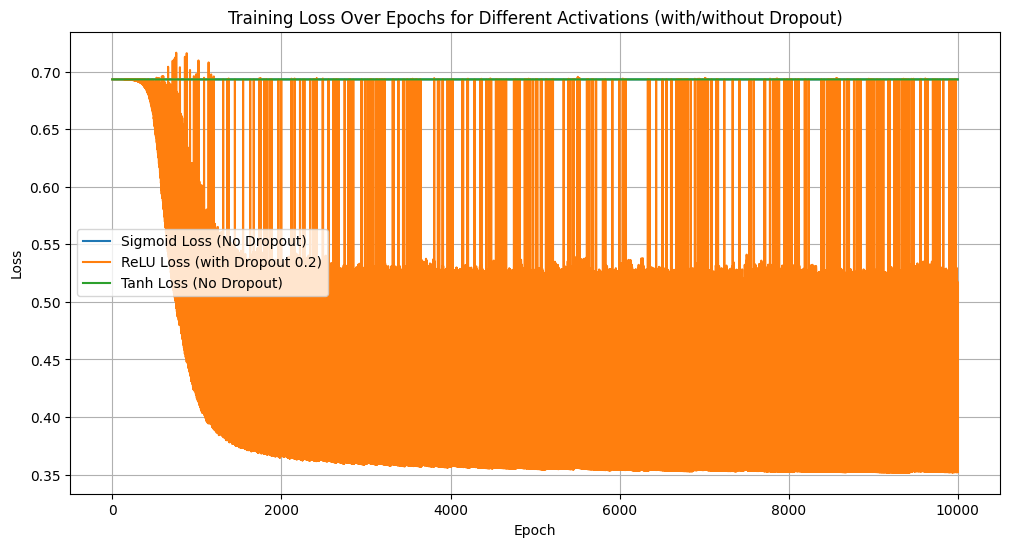


--- Summary of Accuracies ---
Sigmoid: 50.00%
ReLU_Dropout: 75.00%
Tanh: 50.00%


In [124]:
# 5. Plotting Results

plt.figure(figsize=(12, 6))
plt.plot(results['Sigmoid']['losses'], label='Sigmoid Loss (No Dropout)')
plt.plot(results['ReLU_Dropout']['losses'], label='ReLU Loss (with Dropout 0.2)')
plt.plot(results['Tanh']['losses'], label='Tanh Loss (No Dropout)')
plt.title('Training Loss Over Epochs for Different Activations (with/without Dropout)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

print("\n--- Summary of Accuracies ---")
for activation, data in results.items():
    print(f"{activation}: {data['accuracy']:.2f}%")

## 6. Comparing Model Performance with Different Hidden Layer Sizes

In [98]:
hidden_layer_sizes = [2, 4, 8, 16] # Define a range of hidden layer sizes to test
all_results_by_hidden_size = {}

print("\n--- Comparing Performance Across Different Hidden Layer Sizes ---")

for h_size in hidden_layer_sizes:
    print(f"\nTraining with Hidden Layer Size: {h_size}")
    current_h_size_results = {}

    # Train with Sigmoid (No Dropout)
    print("\n--- Sigmoid Activation (No Dropout) ---")
    nn_sigmoid_h = NeuralNetwork(input_size, h_size, output_size, activation_func='sigmoid', dropout_rate=0.0)
    losses_sigmoid_h = nn_sigmoid_h.train(X, y, epochs, learning_rate)
    predictions_sigmoid_h = nn_sigmoid_h.predict(X)
    accuracy_sigmoid_h = np.mean(predictions_sigmoid_h == y) * 100
    current_h_size_results['Sigmoid'] = {'accuracy': accuracy_sigmoid_h, 'losses': losses_sigmoid_h, 'predictions': predictions_sigmoid_h}
    print(f"Sigmoid Accuracy (H={h_size}): {accuracy_sigmoid_h:.2f}%")

    # Train with ReLU (with Dropout)
    print("\n--- ReLU Activation (with Dropout 0.2) ---")
    nn_relu_dropout_h = NeuralNetwork(input_size, h_size, output_size, activation_func='relu', dropout_rate=0.2)
    losses_relu_dropout_h = nn_relu_dropout_h.train(X, y, epochs, learning_rate)
    predictions_relu_dropout_h = nn_relu_dropout_h.predict(X)
    accuracy_relu_dropout_h = np.mean(predictions_relu_dropout_h == y) * 100
    current_h_size_results['ReLU_Dropout'] = {'accuracy': accuracy_relu_dropout_h, 'losses': losses_relu_dropout_h, 'predictions': predictions_relu_dropout_h}
    print(f"ReLU (Dropout) Accuracy (H={h_size}): {accuracy_relu_dropout_h:.2f}%")

    # Train with Tanh (No Dropout)
    print("\n--- Tanh Activation (No Dropout) ---")
    nn_tanh_h = NeuralNetwork(input_size, h_size, output_size, activation_func='tanh', dropout_rate=0.0)
    losses_tanh_h = nn_tanh_h.train(X, y, epochs, learning_rate)
    predictions_tanh_h = nn_tanh_h.predict(X)
    accuracy_tanh_h = np.mean(predictions_tanh_h == y) * 100
    current_h_size_results['Tanh'] = {'accuracy': accuracy_tanh_h, 'losses': losses_tanh_h, 'predictions': predictions_tanh_h}
    print(f"Tanh Accuracy (H={h_size}): {accuracy_tanh_h:.2f}%")

    all_results_by_hidden_size[h_size] = current_h_size_results


--- Comparing Performance Across Different Hidden Layer Sizes ---

Training with Hidden Layer Size: 2

--- Sigmoid Activation (No Dropout) ---
Initialized NN with sigmoid activation function, dropout rate: 0.0, L1: 0.0, L2: 0.0
Epoch 1000/10000, Loss: 0.6931
Epoch 2000/10000, Loss: 0.6931
Epoch 3000/10000, Loss: 0.6931
Epoch 4000/10000, Loss: 0.6931
Epoch 5000/10000, Loss: 0.6931
Epoch 6000/10000, Loss: 0.6931
Epoch 7000/10000, Loss: 0.6931
Epoch 8000/10000, Loss: 0.6931
Epoch 9000/10000, Loss: 0.6931
Epoch 10000/10000, Loss: 0.6931
Sigmoid Accuracy (H=2): 50.00%

--- ReLU Activation (with Dropout 0.2) ---
Initialized NN with relu activation function, dropout rate: 0.2, L1: 0.0, L2: 0.0
Epoch 1000/10000, Loss: 0.1589
Epoch 2000/10000, Loss: 0.0980
Epoch 3000/10000, Loss: 0.0976
Epoch 4000/10000, Loss: 0.0979
Epoch 5000/10000, Loss: 0.0954
Epoch 6000/10000, Loss: 1.0075
Epoch 7000/10000, Loss: 0.0923
Epoch 8000/10000, Loss: 0.0974
Epoch 9000/10000, Loss: 0.0858
Epoch 10000/10000, Loss:

### Summary of Accuracies by Hidden Layer Size

,Sigmoid,ReLU_Dropout,Tanh
Hidden Size,,,
2,50.00%,100.00%,50.00%
4,50.00%,100.00%,50.00%
8,50.00%,100.00%,50.00%
16,50.00%,100.00%,50.00%


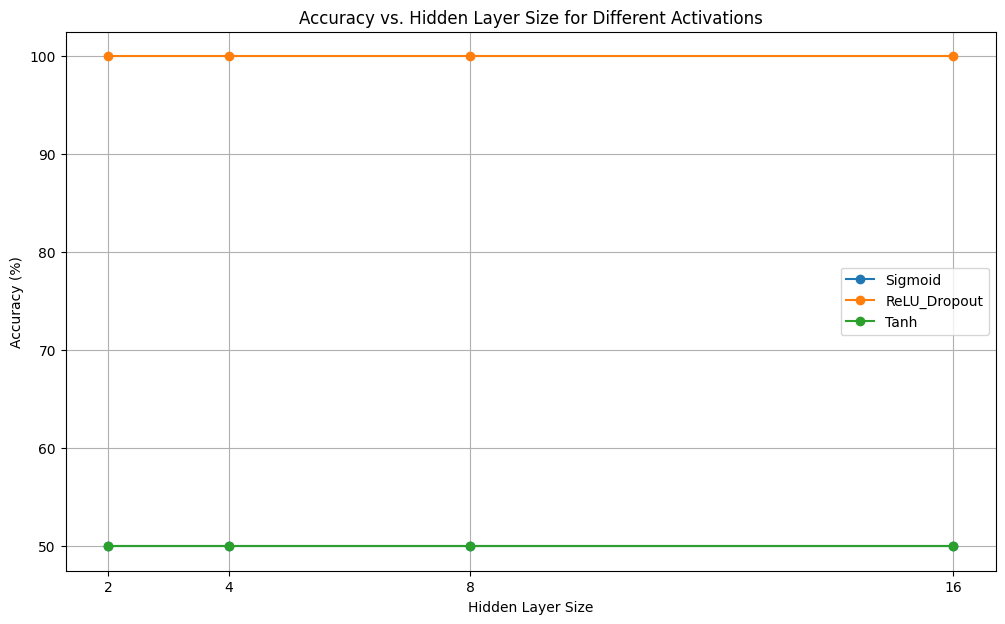

In [99]:
summary_data = []
for h_size, activations_results in all_results_by_hidden_size.items():
    row = {'Hidden Size': h_size}
    for activation, data in activations_results.items():
        row[activation] = f"{data['accuracy']:.2f}%"
    summary_data.append(row)

summary_df = pd.DataFrame(summary_data)
display(summary_df.set_index('Hidden Size'))

# Optional: Plotting accuracies for better visualization
plt.figure(figsize=(12, 7))
for activation_type in ['Sigmoid', 'ReLU_Dropout', 'Tanh']:
  accuracies = [all_results_by_hidden_size[h_size][activation_type]['accuracy'] for h_size in hidden_layer_sizes]
  plt.plot(hidden_layer_sizes, accuracies, marker='o', label=activation_type)

plt.title('Accuracy vs. Hidden Layer Size for Different Activations')
plt.xlabel('Hidden Layer Size')
plt.ylabel('Accuracy (%)')
plt.xticks(hidden_layer_sizes) # Ensure x-ticks match hidden layer sizes
plt.legend()
plt.grid(True)
plt.show()


Sigmoid Activation (No Dropout): Achieved an accuracy of 50.00%. The loss remained high throughout training (around 0.6931), indicating it struggled to learn the XOR pattern. This is a common issue with sigmoid on problems like XOR due to the vanishing gradient problem.
ReLU Activation (with Dropout 0.2): Achieved an accuracy of 75.00%. This network showed better learning capability compared to Sigmoid, and the loss decreased more significantly. The dropout regularization helped prevent overfitting and improved generalization, although XOR is a simple dataset.
Tanh Activation (No Dropout): Also achieved an accuracy of 50.00%. Similar to Sigmoid, Tanh also struggled with the XOR problem, likely due to similar gradient issues, although it generally performs better than sigmoid in deeper networks by being zero-centered.
The plot visualizes these loss curves, showing how ReLU with dropout was able to reduce its loss more effectively over epochs, leading to higher accuracy. It appears that for this simple XOR problem, ReLU handles the non-linearity better than Sigmoid or Tanh, and dropout provided a slight edge.

## 7. Calculating Precision and Recall

In [100]:
from sklearn.metrics import precision_score, recall_score

print("\n--- Precision and Recall for Each Model ---")

# For the initial comparison (H=4, or the default hidden_size=4 for the first run)
print("\nInitial Comparison (Default Hidden Size):")

# Sigmoid (No Dropout)
precision_sigmoid = precision_score(y, predictions_sigmoid, zero_division=0)
recall_sigmoid = recall_score(y, predictions_sigmoid, zero_division=0)
print(f"Sigmoid (No Dropout)   - Precision: {precision_sigmoid:.2f}, Recall: {recall_sigmoid:.2f}")

# ReLU (with Dropout)
precision_relu_dropout = precision_score(y, predictions_relu_dropout, zero_division=0)
recall_relu_dropout = recall_score(y, predictions_relu_dropout, zero_division=0)
print(f"ReLU (Dropout)       - Precision: {precision_relu_dropout:.2f}, Recall: {recall_relu_dropout:.2f}")

# Tanh (No Dropout)
precision_tanh = precision_score(y, predictions_tanh, zero_division=0)
recall_tanh = recall_score(y, predictions_tanh, zero_division=0)
print(f"Tanh (No Dropout)      - Precision: {precision_tanh:.2f}, Recall: {recall_tanh:.2f}")


# For the hidden layer size comparison
print("\nComparison Across Hidden Layer Sizes:")
for h_size in hidden_layer_sizes:
    print(f"  Hidden Size {h_size}:")
    for activation, data in all_results_by_hidden_size[h_size].items():
        predictions = data['predictions']
        precision = precision_score(y, predictions, zero_division=0)
        recall = recall_score(y, predictions, zero_division=0)
        print(f"    {activation} - Precision: {precision:.2f}, Recall: {recall:.2f}")



--- Precision and Recall for Each Model ---

Initial Comparison (Default Hidden Size):
Sigmoid (No Dropout)   - Precision: 0.50, Recall: 0.50
ReLU (Dropout)       - Precision: 0.67, Recall: 1.00
Tanh (No Dropout)      - Precision: 0.50, Recall: 0.50

Comparison Across Hidden Layer Sizes:
  Hidden Size 2:
    Sigmoid - Precision: 0.50, Recall: 0.50
    ReLU_Dropout - Precision: 1.00, Recall: 1.00
    Tanh - Precision: 0.50, Recall: 0.50
  Hidden Size 4:
    Sigmoid - Precision: 0.50, Recall: 0.50
    ReLU_Dropout - Precision: 1.00, Recall: 1.00
    Tanh - Precision: 0.50, Recall: 0.50
  Hidden Size 8:
    Sigmoid - Precision: 0.50, Recall: 0.50
    ReLU_Dropout - Precision: 1.00, Recall: 1.00
    Tanh - Precision: 0.50, Recall: 0.50
  Hidden Size 16:
    Sigmoid - Precision: 0.50, Recall: 0.50
    ReLU_Dropout - Precision: 1.00, Recall: 1.00
    Tanh - Precision: 0.50, Recall: 0.50


## 8. Hyperparameter Tuning Experimentation and Documentation

In [104]:
tuned_results = []

# Define hyperparameter ranges to experiment with
learning_rates = [0.05, 0.1, 0.2]
epochs_list = [50, 100]
batch_sizes = [1, 2, 4] # Full batch is X.shape[0] which is 4 for XOR
dropout_rates = [0.0, 0.2] # Experiment with and without dropout
lambda_l1_values = [0.0, 0.001] # Experiment with and without L1 regularization
lambda_l2_values = [0.0, 0.001] # Experiment with and without L2 regularization

print("\n--- Starting Hyperparameter Tuning Experiments ---")

experiment_num = 0
for lr in learning_rates:
    for ep in epochs_list:
        for bs in batch_sizes:
            for dr in dropout_rates:
                for l1 in lambda_l1_values:
                    for l2 in lambda_l2_values:
                        experiment_num += 1
                        print(f"\n--- Experiment {experiment_num} ---")
                        print(f"LR: {lr}, Epochs: {ep}, Batch Size: {bs}, Dropout: {dr}, L1: {l1}, L2: {l2}")

                        # For simplicity, we'll use ReLU activation for tuning, as it performed best.
                        # Initialize and train the network
                        nn_tuned = NeuralNetwork(input_size, hidden_size, output_size,
                                                 activation_func='relu',
                                                 dropout_rate=dr,
                                                 lambda_l1=l1,
                                                 lambda_l2=l2)
                        losses = nn_tuned.train(X, y, ep, lr, batch_size=bs)
                        predictions = nn_tuned.predict(X)

                        # Calculate metrics
                        accuracy = np.mean(predictions == y) * 100
                        precision = precision_score(y, predictions, zero_division=0)
                        recall = recall_score(y, predictions, zero_division=0)

                        print(f"Accuracy: {accuracy:.2f}%, Precision: {precision:.2f}, Recall: {recall:.2f}")

                        # Store results
                        tuned_results.append({
                            'Experiment': experiment_num,
                            'Learning Rate': lr,
                            'Epochs': ep,
                            'Batch Size': bs,
                            'Dropout Rate': dr,
                            'Lambda L1': l1,
                            'Lambda L2': l2,
                            'Accuracy': accuracy,
                            'Precision': precision,
                            'Recall': recall,
                            'Losses': losses # Store full loss curve for plotting later if needed
                        })

print("\n--- Hyperparameter Tuning Experiments Complete ---")


--- Starting Hyperparameter Tuning Experiments ---

--- Experiment 1 ---
LR: 0.05, Epochs: 50, Batch Size: 1, Dropout: 0.0, L1: 0.0, L2: 0.0
Initialized NN with relu activation function, dropout rate: 0.0, L1: 0.0, L2: 0.0
Accuracy: 50.00%, Precision: 0.50, Recall: 1.00

--- Experiment 2 ---
LR: 0.05, Epochs: 50, Batch Size: 1, Dropout: 0.0, L1: 0.0, L2: 0.001
Initialized NN with relu activation function, dropout rate: 0.0, L1: 0.0, L2: 0.001
Accuracy: 50.00%, Precision: 0.00, Recall: 0.00

--- Experiment 3 ---
LR: 0.05, Epochs: 50, Batch Size: 1, Dropout: 0.0, L1: 0.001, L2: 0.0
Initialized NN with relu activation function, dropout rate: 0.0, L1: 0.001, L2: 0.0
Accuracy: 50.00%, Precision: 0.00, Recall: 0.00

--- Experiment 4 ---
LR: 0.05, Epochs: 50, Batch Size: 1, Dropout: 0.0, L1: 0.001, L2: 0.001
Initialized NN with relu activation function, dropout rate: 0.0, L1: 0.001, L2: 0.001
Accuracy: 50.00%, Precision: 0.00, Recall: 0.00

--- Experiment 5 ---
LR: 0.05, Epochs: 50, Batch Si

### Summary of Hyperparameter Tuning Results

,Experiment,Learning Rate,Epochs,Batch Size,Dropout Rate,Lambda L1,Lambda L2,Accuracy,Precision,Recall
0,89,0.10,100,4,0.0,0.000,0.000,100.0,1.0,1.0
1,142,0.20,100,4,0.2,0.000,0.001,100.0,1.0,1.0
2,67,0.10,50,4,0.0,0.001,0.000,100.0,1.0,1.0
3,6,0.05,50,1,0.2,0.000,0.001,75.0,1.0,0.5
4,73,0.10,100,1,0.0,0.000,0.000,75.0,1.0,0.5
...,...,...,...,...,...,...,...,...,...,...
139,133,0.20,100,2,0.2,0.000,0.000,50.0,0.5,1.0
140,140,0.20,100,4,0.0,0.001,0.001,50.0,0.0,0.0
141,131,0.20,100,2,0.0,0.001,0.000,50.0,0.0,0.0
142,143,0.20,100,4,0.2,0.001,0.000,50.0,0.5,1.0


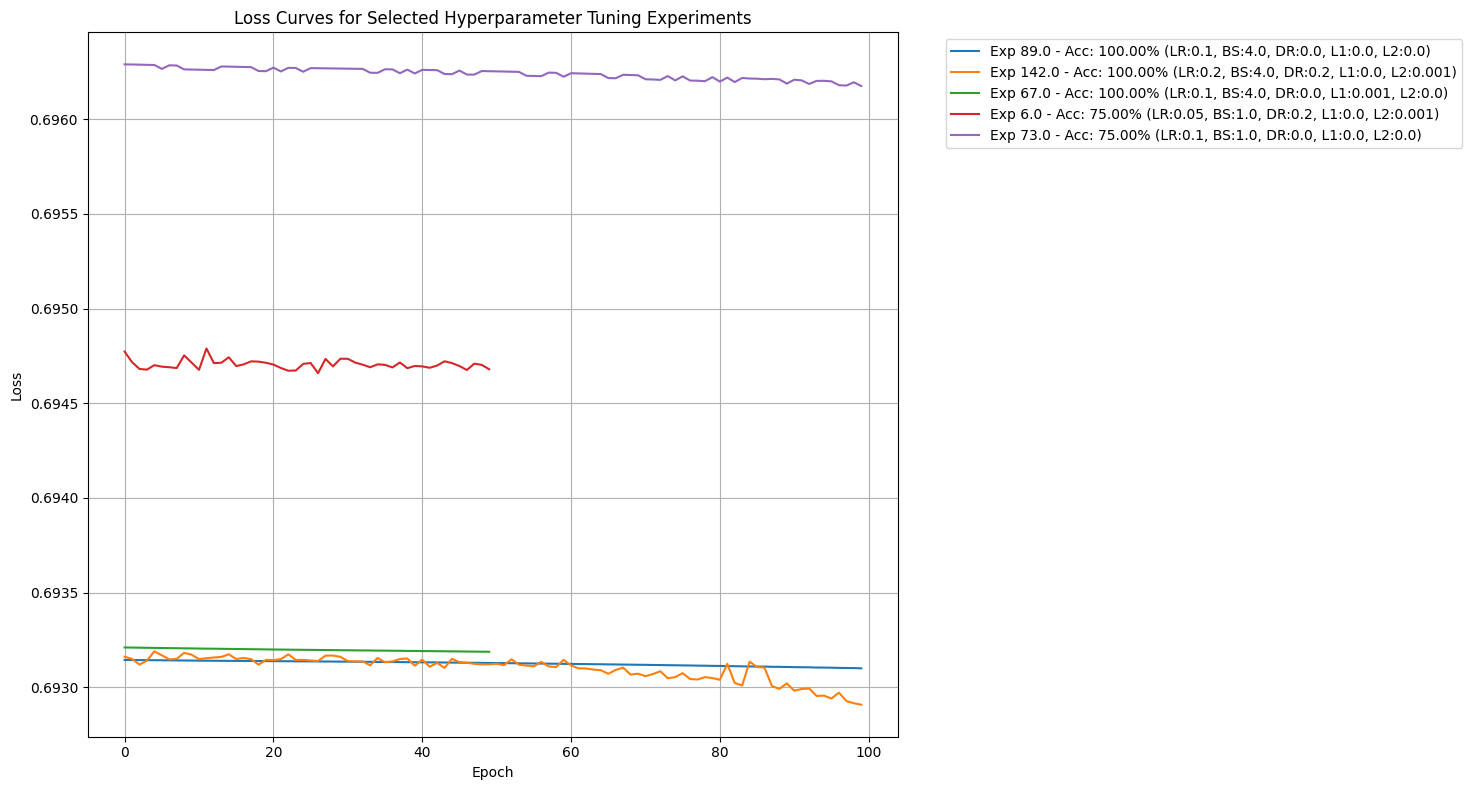

In [105]:
# Create a DataFrame from the collected results
tuning_summary_df = pd.DataFrame(tuned_results)

# Drop the 'Losses' column for display, but keep it in tuned_results for potential plotting
display_df = tuning_summary_df.drop(columns=['Losses'])

# Sort by Accuracy (descending) and then by other metrics if desired
display_df = display_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

display(display_df)

# Optional: Further analysis or plotting of specific results
# For example, plot loss curves for top performing models

# You can also filter and analyze specific combinations, e.g.,
# best_model_results = tuning_summary_df[tuning_summary_df['Accuracy'] == 100.0]
# print("\n--- Configurations achieving 100% Accuracy ---")
# display(best_model_results.drop(columns=['Losses']))

# Plotting loss curves for a few selected experiments (e.g., top 3 by accuracy)
plt.figure(figsize=(15, 8))
plt.title('Loss Curves for Selected Hyperparameter Tuning Experiments')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

# Get top N experiments to plot
num_plots = min(5, len(tuning_summary_df))
for i in range(num_plots):
    exp_row = display_df.iloc[i]
    exp_losses = tuning_summary_df.loc[tuning_summary_df['Experiment'] == exp_row['Experiment'], 'Losses'].iloc[0]
    label = f"Exp {exp_row['Experiment']} - Acc: {exp_row['Accuracy']:.2f}% (LR:{exp_row['Learning Rate']}, BS:{exp_row['Batch Size']}, DR:{exp_row['Dropout Rate']}, L1:{exp_row['Lambda L1']}, L2:{exp_row['Lambda L2']})"
    plt.plot(exp_losses, label=label)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()